## **Customer Retention & Transaction Analytics**

#### Import Libaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

#### Load Data from Database

In [2]:
# pip install mysql-connector-python pandas

In [3]:
import mysql.connector

In [4]:
from getpass import getpass

connection = mysql.connector.connect(
    host='localhost',
    user='root',
    password=getpass('Enter MySQL password: '),
    database='rt'
)
print('Connected to MySQL successfully')

Enter MySQL password:  ········


Connected to MySQL successfully


#### Access Tables

In [5]:
customers =pd.read_sql(
    'SELECT * FROM customers',
    connection
)

products =pd.read_sql(
    'SELECT * FROM products',
    connection
)

date_table =pd.read_sql(
    'SELECT * FROM date_table',
    connection
)

transactions =pd.read_sql(
    'SELECT * FROM transactions',
    connection
)

customers_support =pd.read_sql(
    'SELECT * FROM customers_support',
    connection
)

In [6]:
for name,df in[('customers',customers),('products',products),
               ('date_table',date_table),('transactions',transactions),
               ('customers_support',customers_support)]:
    print('-'*70)
    print(name)
    print('Total Rows Counts:',len(df))
    print('-'*70)
    print('Dataset Shape',df.shape)
    print('Data Types \n',df.dtypes)
    print('\n',df.head(10))
    print()

----------------------------------------------------------------------
customers
Total Rows Counts: 7000
----------------------------------------------------------------------
Dataset Shape (7000, 4)
Data Types 
 customer_id                  object
signup_date                  object
location_clean_city          object
acquisition_clean_channel    object
dtype: object

   customer_id signup_date location_clean_city acquisition_clean_channel
0   CUST-0001  2025-05-11              Mumbai                   Organic
1   CUST-0002  2024-03-27           Bangalore                  Referral
2   CUST-0003  2024-01-20              Mumbai                    Social
3   CUST-0004  2025-07-29             Kolkata                   Unknown
4   CUST-0005  2024-08-01              Mumbai                    Social
5   CUST-0006  2024-07-09              Mumbai                  Paid Ads
6   CUST-0007  2024-06-22              Mumbai                  Referral
7   CUST-0008  2024-04-18             Kolkata      

#### convert date columns to datetime

In [7]:
customers['signup_date']=pd.to_datetime(
    customers['signup_date']
)

date_table['date_key'] =pd.to_datetime(
    date_table['date_key']
)

transactions['transaction_date']=pd.to_datetime(
    transactions['transaction_date']
)

customers_support['ticket_date'] =pd.to_datetime(
    customers_support['ticket_date']
)

In [8]:
print(customers.dtypes,'\n')
print(date_table.dtypes,'\n')
print(transactions.dtypes,'\n')
print(customers_support.dtypes,'\n')

customer_id                          object
signup_date                  datetime64[ns]
location_clean_city                  object
acquisition_clean_channel            object
dtype: object 

date_key        datetime64[ns]
year                     int64
quarter                  int64
month                    int64
month_name              object
day_of_month             int64
day_of_week             object
is_weekend               int64
dtype: object 

transaction_id               object
customer_id                  object
product_id                   object
transaction_date     datetime64[ns]
transaction_time    timedelta64[ns]
quantity                      int64
unit_price                  float64
discount_amount             float64
total_amount                float64
payment_method               object
order_status                 object
dtype: object 

ticket_id                      object
customer_id                    object
transaction_id                 object
ticket_date       

All five tables were successfully loaded into Python, with 24,244 transactions, 7,000 customers, 50 products, 1,156 dates, and 6,035 support tickets available for analysis.

#### Data Cleaning Confirmation 

In [9]:
transactions[['customer_id','product_id','total_amount']].isnull().sum()

customer_id     0
product_id      0
total_amount    0
dtype: int64

In [10]:
support_null =customers_support[
        customers_support['resolution_hours'].isnull() |
        customers_support['satisfaction_score'].isnull()
]

print('Support records with missing values: ',len(support_null))

Support records with missing values:  1609


In [11]:
customers_support[
        customers_support['resolution_hours'].isnull() |
        customers_support['satisfaction_score'].isnull()
]['ticket_status'].value_counts()

ticket_status
Pending      1006
Escalated     603
Name: count, dtype: int64

In [12]:
transactions['transaction_id'].duplicated().sum()

np.int64(0)

In [13]:
customers_support['ticket_id'].duplicated().sum()

np.int64(0)

In [14]:
print(customers['location_clean_city'].unique())

['Mumbai' 'Bangalore' 'Kolkata' 'Delhi' 'Unknown' 'Chennai' 'Pune']


In [15]:
print(customers['acquisition_clean_channel'].unique())

['Organic' 'Referral' 'Social' 'Unknown' 'Paid Ads']


The Python data matches the cleaned Excel and SQL data, and the key fields and relationships are ready for analysis.

#### Exploratory Data Analysis

In [16]:
transactions['total_amount'].describe()

count     24244.000000
mean       1721.380166
std        6143.518259
min         149.250000
25%         498.000000
50%         799.000000
75%        1299.000000
max      143904.000000
Name: total_amount, dtype: float64

In [17]:
transactions['quantity'].agg(
    ['count', 'sum', 'mean', 'median', 'min', 'max']
)

count     24244.0000
sum       65837.0000
mean          2.7156
median        1.0000
min           1.0000
max         100.0000
Name: quantity, dtype: float64

In [18]:
transactions['order_status'].value_counts()

order_status
Completed    19420
Returned      3035
Cancelled     1203
Refunded       586
Name: count, dtype: int64

In [19]:
transactions['payment_method'].value_counts()

payment_method
UPI            10875
Credit Card     8388
Net Banking     2539
Cash            2442
Name: count, dtype: int64

In [20]:
bulk_orders = transactions[transactions['quantity'] > 10]

print("Bulk Orders:", len(bulk_orders))

Bulk Orders: 457


In [21]:
transactions['Quantity_Status'] = transactions['quantity'].apply(
    lambda x: 'Bulk Order' if x > 10 else 'Standard Order'
)
transactions['Quantity_Status'].value_counts()

Quantity_Status
Standard Order    23787
Bulk Order          457
Name: count, dtype: int64

In [22]:
status_analysis =(
    transactions
    .groupby('order_status')
    .agg(
        transactions_count =('transaction_id','count'),
        total_revenue =('total_amount','sum')
    )
    .reset_index()
)
status_analysis

,order_status,transactions_count,total_revenue
0,Cancelled,1203,2341701.50
1,Completed,19420,33133954.30
2,Refunded,586,994550.35
3,Returned,3035,5262934.60


In [23]:
transactions_product =transactions.merge(
    products[['product_id','product_category']],
    on='product_id',
    how='left'
)

In [24]:
print(transactions_product.shape)

(24244, 13)


In [25]:
transactions_product

,transaction_id,customer_id,product_id,transaction_date,transaction_time,quantity,unit_price,discount_amount,total_amount,payment_method,order_status,Quantity_Status,product_category
0,TXN-00001,CUST-0001,PROD-043,2025-12-10,0 days 14:52:42,2,799.0,0.0,1598.0,Credit Card,Completed,Standard Order,Sports
1,TXN-00002,CUST-0002,PROD-004,2024-03-27,0 days 21:40:11,2,1499.0,0.0,2998.0,UPI,Completed,Standard Order,Electronics
2,TXN-00003,CUST-0002,PROD-043,2024-07-04,0 days 15:25:22,1,799.0,0.0,799.0,Credit Card,Completed,Standard Order,Sports
3,TXN-00004,CUST-0002,PROD-035,2024-07-07,0 days 02:34:00,1,399.0,0.0,399.0,UPI,Completed,Standard Order,Beauty
4,TXN-00005,CUST-0002,PROD-004,2024-08-02,0 days 13:07:24,1,1499.0,299.8,1199.2,Net Banking,Returned,Standard Order,Electronics
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24239,TXN-24240,CUST-6998,PROD-050,2025-11-08,0 days 16:40:32,2,1299.0,649.5,1948.5,Cash,Completed,Standard Order,Sports
24240,TXN-24241,CUST-6998,PROD-050,2025-10-17,0 days 00:48:59,2,1299.0,259.8,2338.2,UPI,Completed,Standard Order,Sports
24241,TXN-24242,CUST-6999,PROD-012,2025-04-28,0 days 07:21:25,2,799.0,0.0,1598.0,Cash,Completed,Standard Order,Apparel
24242,TXN-24243,CUST-7000,PROD-006,2024-12-06,0 days 10:33:28,1,499.0,49.9,449.1,Net Banking,Completed,Standard Order,Electronics


In [26]:
category_revenue = (
    transactions_product
    .groupby('product_category')
    .agg(
        transaction_count=('transaction_id', 'count'),
        total_revenue=('total_amount', 'sum')
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

category_revenue

,product_category,transaction_count,total_revenue
2,Electronics,4884,10458205.40
3,Home,4783,10279610.40
0,Apparel,4927,9170716.60
4,Sports,4812,7128318.80
1,Beauty,4838,4696289.55


In [27]:
transaction_customer =transactions.merge(
    customers[['customer_id','location_clean_city']],
    on='customer_id',
    how='left'
)

In [28]:
print(transaction_customer.shape)

(24244, 13)


In [29]:
transaction_customer_product = transaction_customer.merge(
    products[['product_id', 'product_category']],
    on='product_id',
    how='left'
)

In [30]:
print(transaction_customer_product.shape)

(24244, 14)


In [31]:
city_category_revenue =(
    transaction_customer_product
    .groupby(
        ['location_clean_city','product_category']
    )
    .agg(
        transaction_count =('transaction_id','count'),
        total_revenue =('total_amount','sum')
    )
    .reset_index()
    .sort_values('total_revenue',ascending=False)
)

city_category_revenue

,location_clean_city,product_category,transaction_count,total_revenue
23,Mumbai,Home,1091,2488114.10
20,Mumbai,Apparel,1165,2403452.90
22,Mumbai,Electronics,1074,2245659.70
13,Delhi,Home,973,2228954.70
2,Bangalore,Electronics,969,2223502.35
10,Delhi,Apparel,969,2068834.35
3,Bangalore,Home,949,1936355.50
12,Delhi,Electronics,1002,1851127.55
0,Bangalore,Apparel,976,1752562.95
7,Chennai,Electronics,793,1630239.55


In [32]:
print("Original:", len(transactions))
print("After Product Merge:", len(transactions_product))
print("After Customer Merge:", len(transaction_customer))
print("After Final Merge:", len(transaction_customer_product))

Original: 24244
After Product Merge: 24244
After Customer Merge: 24244
After Final Merge: 24244


In [33]:
category_revenue

,product_category,transaction_count,total_revenue
2,Electronics,4884,10458205.40
3,Home,4783,10279610.40
0,Apparel,4927,9170716.60
4,Sports,4812,7128318.80
1,Beauty,4838,4696289.55


In [34]:
city_revenue = (
    transaction_customer
    .groupby('location_clean_city')
    .agg(
        transaction_count=('transaction_id', 'count'),
        total_revenue=('total_amount', 'sum')
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

city_revenue

,location_clean_city,transaction_count,total_revenue
4,Mumbai,5540,9668221.30
2,Delhi,4916,8660230.50
0,Bangalore,4797,8374254.10
1,Chennai,3715,5846923.10
3,Kolkata,2342,4122816.60
5,Pune,1888,3162703.20
6,Unknown,1046,1897991.95


In [35]:
print(customers['customer_id'].is_unique)
print(products['product_id'].is_unique)

True
True


The data shows that revenue is mainly driven by Electronics, Home, and Apparel, while transaction quantities are mostly small with a small number of large bulk orders.

#### Statistical Analysis

In [36]:
statistical_summary = transactions[
    ['total_amount', 'quantity']
].agg(['mean', 'median', 'std'])

statistical_summary

,total_amount,quantity
mean,1721.380166,2.715600
median,799.000000,1.000000
std,6143.518259,8.635191


In [37]:
quantity_percentiles = transactions['quantity'].quantile(
    [0.50, 0.90, 0.95, 0.99]
)

quantity_percentiles

0.50     1.0
0.90     3.0
0.95     4.0
0.99    57.0
Name: quantity, dtype: float64

In [38]:
quantity_percentiles.index = [
    '50th Percentile',
    '90th Percentile',
    '95th Percentile',
    '99th Percentile'
]

quantity_percentiles

50th Percentile     1.0
90th Percentile     3.0
95th Percentile     4.0
99th Percentile    57.0
Name: quantity, dtype: float64

In [39]:
Q1 = transactions['quantity'].quantile(0.25)
Q3 = transactions['quantity'].quantile(0.75)

In [40]:
IQR =Q3-Q1

In [41]:
upper_limit = Q3 + (1.5 * IQR)

In [42]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper Outlier Limit:", upper_limit)

Q1: 1.0
Q3: 2.0
IQR: 1.0
Upper Outlier Limit: 3.5


In [43]:
statistical_outliers = transactions[
    transactions['quantity'] > upper_limit
]

print("Statistical Outliers:", len(statistical_outliers))

Statistical Outliers: 1601


In [44]:
comparison = pd.DataFrame({
    'Method': [
        'Business Bulk Order',
        'IQR Statistical Outlier'
    ],
    'Threshold': [
        10,
        upper_limit
    ],
    'Record_Count': [
        len(bulk_orders),
        len(statistical_outliers)
    ]
})

comparison

,Method,Threshold,Record_Count
0,Business Bulk Order,10.0,457
1,IQR Statistical Outlier,3.5,1601


**Interpretation — Business Rule vs. Statistical Outlier Threshold**

The business rule (`quantity > 10`) flags **457** transactions (1.9% of all transactions) as Bulk Orders.
The IQR statistical method flags **1,601** transactions (6.6%) using a much lower threshold (~3.5 units).

This gap tells us the "Bulk Order" flag is a deliberate business threshold, not a pure statistical outlier boundary — it's likely designed to isolate genuinely large, possibly wholesale-style purchases rather than every transaction that is merely "above typical." Both numbers are legitimate; they just answer different questions:
- **Business rule (457):** "which orders look like bulk/wholesale purchases?"
- **IQR method (1,601):** "which orders are statistically unusual relative to the rest of the data?"

For retention and segmentation purposes, the business rule is more useful since it targets a specific buyer behavior. The IQR result is kept here as a cross-check, not a replacement.

In [45]:
correlation = transactions[
    [
        'quantity',
        'unit_price',
        'discount_amount',
        'total_amount'
    ]
].corr()

correlation

,quantity,unit_price,discount_amount,total_amount
quantity,1.000000,-0.004994,0.483030,0.874051
unit_price,-0.004994,1.000000,0.074614,0.139167
discount_amount,0.483030,0.074614,1.000000,0.456376
total_amount,0.874051,0.139167,0.456376,1.000000


Transaction quantity is right-skewed, meaning most customers buy small quantities while a few transactions have unusually large quantities.

#### Customer Analysis in Python

In [46]:
customer_summary = (
    transactions
    .groupby('customer_id')
    .agg(
        total_transactions=('transaction_id', 'count'),
        total_revenue=('total_amount', 'sum'),
        first_purchase_date=('transaction_date', 'min'),
        last_purchase_date=('transaction_date', 'max')
    )
    .reset_index()
)

customer_summary.head()

,customer_id,total_transactions,total_revenue,first_purchase_date,last_purchase_date
0,CUST-0001,1,1598.0,2025-12-10,2025-12-10
1,CUST-0002,11,67581.3,2024-03-27,2025-08-04
2,CUST-0003,3,792.6,2024-11-12,2025-08-10
3,CUST-0004,2,2474.2,2025-11-24,2025-12-17
4,CUST-0005,1,899.0,2024-12-25,2024-12-25


In [47]:
print("Customer count:", len(customer_summary))

Customer count: 7000


In [48]:
max_transaction_date = transactions['transaction_date'].max()

print("Dataset maximum transaction date:", max_transaction_date)

Dataset maximum transaction date: 2025-12-31 00:00:00


In [49]:
customer_summary['days_since_last_purchase'] = (
    max_transaction_date -
    customer_summary['last_purchase_date']
).dt.days

In [50]:
customer_summary[
    [
        'customer_id',
        'last_purchase_date',
        'days_since_last_purchase'
    ]
].head()

,customer_id,last_purchase_date,days_since_last_purchase
0,CUST-0001,2025-12-10,21
1,CUST-0002,2025-08-04,149
2,CUST-0003,2025-08-10,143
3,CUST-0004,2025-12-17,14
4,CUST-0005,2024-12-25,371


In [51]:
customer_summary['customer_type'] = customer_summary[
    'total_transactions'
].apply(
    lambda x: 'One-Time' if x == 1 else 'Repeat'
)

In [52]:
customer_summary['inactive_180_plus'] = (
    customer_summary['days_since_last_purchase'] > 180
)

In [53]:
customer_summary[
    [
        'customer_id',
        'total_transactions',
        'total_revenue',
        'customer_type',
        'days_since_last_purchase',
        'inactive_180_plus'
    ]
].head(10)

,customer_id,total_transactions,total_revenue,customer_type,days_since_last_purchase,inactive_180_plus
0,CUST-0001,1,1598.00,One-Time,21,False
1,CUST-0002,11,67581.30,Repeat,149,False
2,CUST-0003,3,792.60,Repeat,143,False
3,CUST-0004,2,2474.20,Repeat,14,False
4,CUST-0005,1,899.00,One-Time,371,True
5,CUST-0006,1,897.75,One-Time,446,True
6,CUST-0007,1,423.30,One-Time,399,True
7,CUST-0008,6,5861.80,Repeat,6,False
8,CUST-0009,2,1290.90,Repeat,18,False
9,CUST-0010,3,3526.20,Repeat,138,False


In [54]:
one_time_count = (
    customer_summary['customer_type'] == 'One-Time'
).sum()

print("One-Time Customers:", one_time_count)

One-Time Customers: 3093


In [55]:
repeat_count = (
    customer_summary['customer_type'] == 'Repeat'
).sum()

print("Repeat Customers:", repeat_count)

Repeat Customers: 3907


In [56]:
print(one_time_count + repeat_count)

7000


In [57]:
inactive_count = (
    customer_summary['inactive_180_plus']
).sum()

print("Inactive Customers:", inactive_count)

Inactive Customers: 1394


#### RFM

In [58]:
customer_summary['R_score'] = pd.qcut(
    customer_summary['days_since_last_purchase'].rank(method='first', ascending=False),
    5,
    labels=[5, 4, 3, 2, 1]
)


In [59]:
customer_summary['F_score'] = pd.qcut(
    customer_summary['total_transactions'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [60]:
customer_summary['M_score'] = pd.qcut(
    customer_summary['total_revenue'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [61]:
customer_summary['RFM_score'] = (
    customer_summary['R_score'].astype(str) +
    customer_summary['F_score'].astype(str) +
    customer_summary['M_score'].astype(str)
)

In [62]:
customer_summary[
    [
        'customer_id',
        'R_score',
        'F_score',
        'M_score',
        'RFM_score'
    ]
].head(10)

,customer_id,R_score,F_score,M_score,RFM_score
0,CUST-0001,2,1,3,213
1,CUST-0002,4,5,5,455
2,CUST-0003,4,4,2,442
3,CUST-0004,2,3,3,233
4,CUST-0005,5,1,2,512
5,CUST-0006,5,1,2,512
6,CUST-0007,5,1,1,511
7,CUST-0008,1,5,5,155
8,CUST-0009,2,3,2,232
9,CUST-0010,4,4,4,444


In [63]:
validation = pd.DataFrame({
    'Customer Segment': [
        'One-Time',
        'Repeat',
        'Inactive 180+ Days'
    ],
    'Python Count': [
        one_time_count,
        repeat_count,
        inactive_count
    ],
    'Expected Count': [
        3093,
        3907,
        1394
    ]
})

validation['Match'] = (
    validation['Python Count'] ==
    validation['Expected Count']
)

validation

,Customer Segment,Python Count,Expected Count,Match
0,One-Time,3093,3093,True
1,Repeat,3907,3907,True
2,Inactive 180+ Days,1394,1394,True


There are more Repeat Customers (3,907) than One-Time Customers (3,093), showing that returning customers make up the larger customer group.

#### Trend Analysis

In [64]:
monthly_analysis = (
    transactions
    .groupby(
        transactions['transaction_date'].dt.to_period('M')
    )
    .agg(
        monthly_revenue=('total_amount', 'sum'),
        transaction_count=('transaction_id', 'count')
    )
    .reset_index()
)

monthly_analysis['transaction_date'] = (
    monthly_analysis['transaction_date']
    .dt.to_timestamp()
)

monthly_analysis

,transaction_date,monthly_revenue,transaction_count
0,2024-01-01,183992.30,22
1,2024-02-01,226996.20,55
2,2024-03-01,76848.15,69
3,2024-04-01,271206.00,85
4,2024-05-01,136178.85,113
5,2024-06-01,591558.85,331
6,2024-07-01,999635.90,640
7,2024-08-01,1382936.15,795
8,2024-09-01,560495.35,447
9,2024-10-01,525049.55,498


In [65]:
monthly_analysis = monthly_analysis.sort_values(
    'transaction_date'
)

In [66]:
monthly_analysis['previous_month_revenue'] = (
    monthly_analysis['monthly_revenue'].shift(1)
)

In [67]:
monthly_analysis['revenue_change'] = (
    monthly_analysis['monthly_revenue']
    - monthly_analysis['previous_month_revenue']
)

In [68]:
monthly_analysis['revenue_change_pct'] = (
    monthly_analysis['revenue_change']
    / monthly_analysis['previous_month_revenue']
) * 100

In [69]:
monthly_analysis.head(10)

,transaction_date,monthly_revenue,transaction_count,previous_month_revenue,revenue_change,revenue_change_pct
0,2024-01-01,183992.30,22,NaN,NaN,NaN
1,2024-02-01,226996.20,55,183992.30,43003.90,23.372663
2,2024-03-01,76848.15,69,226996.20,-150148.05,-66.145623
3,2024-04-01,271206.00,85,76848.15,194357.85,252.911553
4,2024-05-01,136178.85,113,271206.00,-135027.15,-49.787671
5,2024-06-01,591558.85,331,136178.85,455380.00,334.398477
6,2024-07-01,999635.90,640,591558.85,408077.05,68.983340
7,2024-08-01,1382936.15,795,999635.90,383300.25,38.343986
8,2024-09-01,560495.35,447,1382936.15,-822440.80,-59.470627
9,2024-10-01,525049.55,498,560495.35,-35445.80,-6.324013


In [70]:
transaction_date = transactions.merge(
    date_table[
        ['date_key', 'day_of_week', 'is_weekend']
    ],
    left_on='transaction_date',
    right_on='date_key',
    how='left'
)

In [71]:
print(transaction_date.shape)

(24244, 15)


In [72]:
transaction_date['day_type'] = transaction_date[
    'is_weekend'
].map({
    0: 'Weekday',
    1: 'Weekend'
})

In [73]:
weekday_weekend = (
    transaction_date
    .groupby('day_type')
    .agg(
        transaction_count=('transaction_id', 'count'),
        total_revenue=('total_amount', 'sum')
    )
    .reset_index()
)

weekday_weekend

,day_type,transaction_count,total_revenue
0,Weekday,17345,28847156.40
1,Weekend,6899,12885984.35


In [74]:
transaction_category = transactions.merge(
    products[
        ['product_id', 'product_category']
    ],
    on='product_id',
    how='left'
)

In [75]:
print(transaction_category.shape)

(24244, 13)


In [76]:
category_monthly_revenue = (
    transaction_category
    .groupby([
        transaction_category['transaction_date'].dt.to_period('M'),
        'product_category'
    ])
    .agg(
        total_revenue=('total_amount', 'sum')
    )
    .reset_index()
)

In [77]:
category_monthly_revenue['transaction_date'] = (
    category_monthly_revenue['transaction_date']
    .dt.to_timestamp()
)

In [78]:
category_monthly_revenue = (
    category_monthly_revenue
    .sort_values(
        ['transaction_date', 'product_category']
    )
)

In [79]:
print("Transactions:", len(transactions))
print("After Date Merge:", len(transaction_date))
print("After Product Merge:", len(transaction_category))

Transactions: 24244
After Date Merge: 24244
After Product Merge: 24244


In [80]:
monthly_analysis[
    ['transaction_date', 'monthly_revenue']
]

,transaction_date,monthly_revenue
0,2024-01-01,183992.30
1,2024-02-01,226996.20
2,2024-03-01,76848.15
3,2024-04-01,271206.00
4,2024-05-01,136178.85
5,2024-06-01,591558.85
6,2024-07-01,999635.90
7,2024-08-01,1382936.15
8,2024-09-01,560495.35
9,2024-10-01,525049.55


Monthly revenue changes sharply over time, with some strong increases and drops, and the highest revenue appears toward the end of 2025.

#### Visualization 

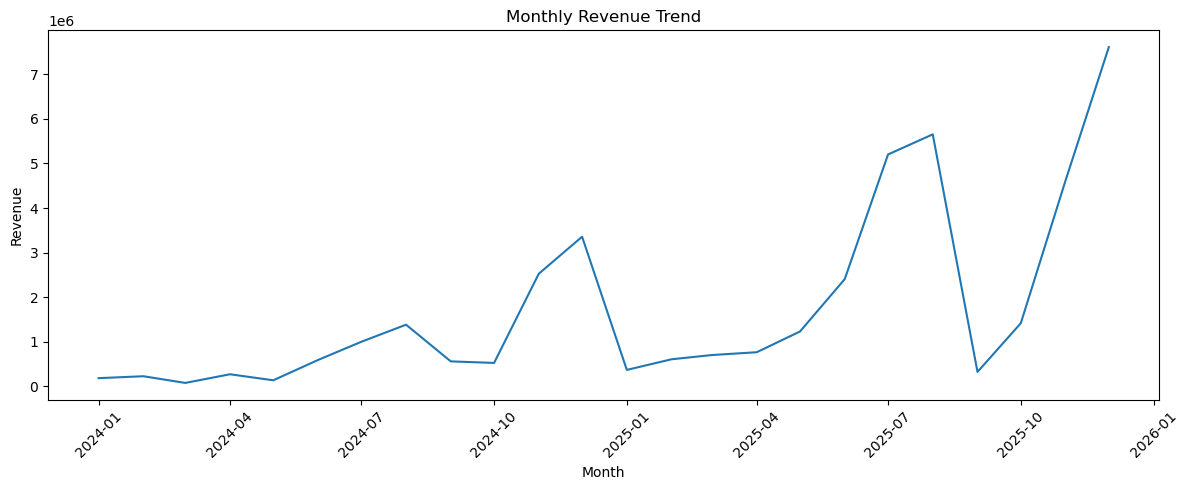

In [81]:
# Line chart: Monthly Revenue Trend
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_analysis['transaction_date'],
    monthly_analysis['monthly_revenue']
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Revenue fluctuates significantly month to month, with the highest revenue occurring toward the end of 2025.

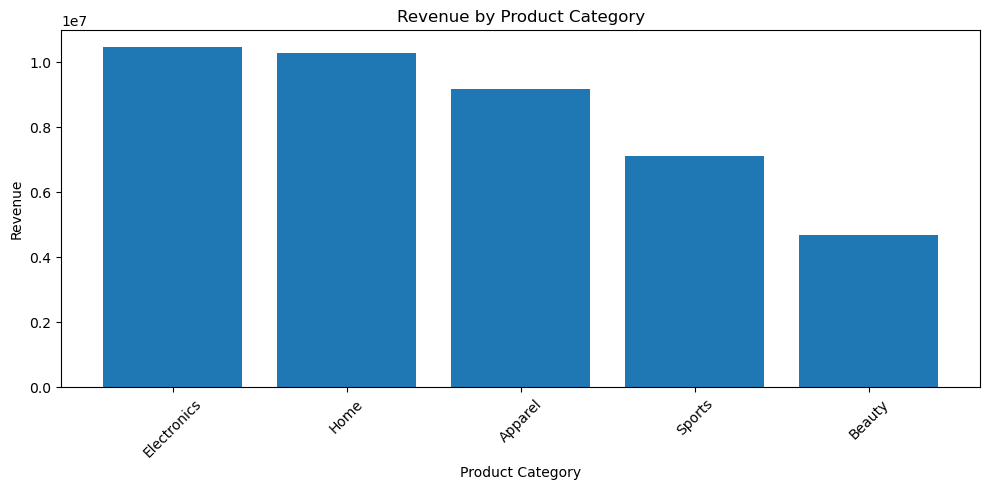

In [82]:
# Bar chart: Revenue by Product Category
category_revenue = (
    transactions_product
    .groupby('product_category')['total_amount']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
plt.bar(
    category_revenue.index,
    category_revenue.values
)

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Electronics generates the highest revenue, followed by Home and Apparel, while Beauty generates the lowest.

In [83]:
customer_type_counts = (
    customer_summary['customer_type']
    .value_counts()
)

customer_type_counts

customer_type
Repeat      3907
One-Time    3093
Name: count, dtype: int64

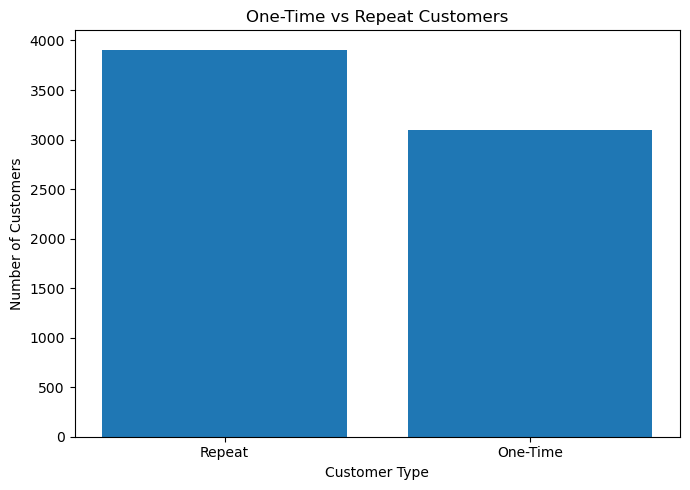

In [84]:
# Bar chart: One-Time vs Repeat Customers
plt.figure(figsize=(7, 5))
plt.bar(
    customer_type_counts.index,
    customer_type_counts.values
)

plt.title('One-Time vs Repeat Customers')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

Repeat customers outnumber one-time customers, showing a stronger base of returning customers.

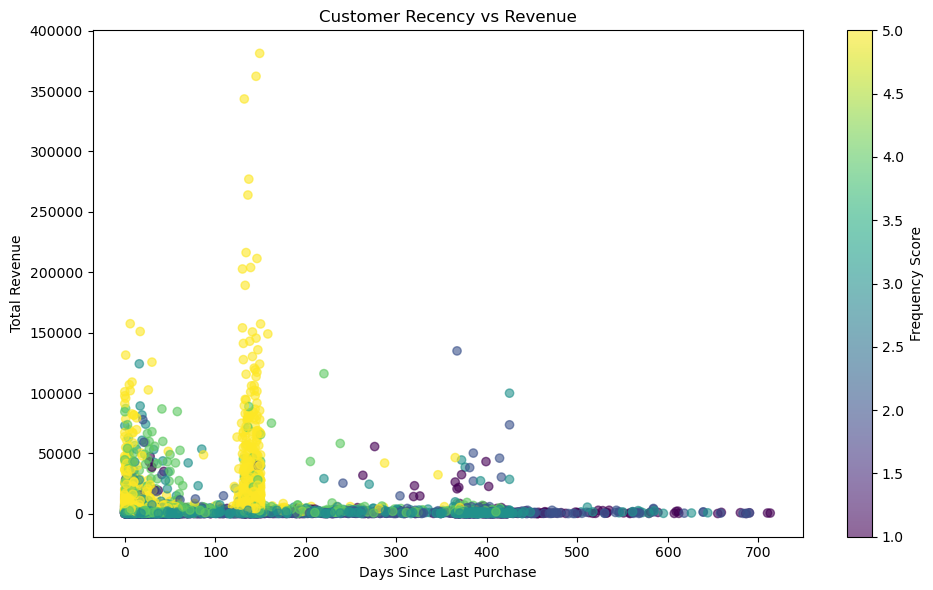

In [85]:
# Scatter Plot: Recency vs Revenue
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    customer_summary['days_since_last_purchase'],
    customer_summary['total_revenue'],
    c=customer_summary['F_score'].astype(int),
    alpha=0.6
)

plt.title('Customer Recency vs Revenue')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Total Revenue')
plt.colorbar(
    scatter,
    label='Frequency Score'
)
plt.tight_layout()
plt.show()

Most customers generate relatively low revenue, while a small number of recent and frequent customers contribute disproportionately high revenue.

## Key Business Insights

Each finding below follows: **Observation → Evidence → Interpretation → Business Action**.

### 1. Bulk Orders are a distinct, deliberate segment — not data errors

- **Observation:** 457 transactions (1.9%) have a quantity greater than 10 units, with some as high as 100.
- **Evidence:** `unit_price` and `total_amount` remain internally consistent for these rows (verified during Excel/SQL validation) — the values are not corrupted or duplicated. The IQR statistical method independently flags a much larger set (1,601 rows), confirming these are genuinely on the high end of the distribution, not typical purchases.
- **Interpretation:** These are likely legitimate large-volume purchases (possibly small-business or wholesale-style buyers) rather than errors, since nothing about the surrounding data looks broken.
- **Business Action:** Investigate whether these customers merit a separate account type or pricing tier, since they may represent a distinct, higher-value buyer segment worth targeting differently from typical retail customers.

### 2. A majority of customers are repeat buyers, but one in five has gone inactive

- **Observation:** 55.8% of customers (3,907) are repeat buyers; 44.2% (3,093) have purchased only once. Separately, 1,394 customers (19.9%) have not purchased in 180+ days.
- **Evidence:** Confirmed identically across Excel, SQL, and this Python analysis — three independent calculations agree exactly (3,907 / 3,093 / 1,394).
- **Interpretation:** The repeat rate suggests the core customer base is reasonably loyal, but the inactive segment is large enough to represent a meaningful revenue risk if left unaddressed.
- **Business Action:** Prioritize a win-back campaign targeted specifically at the 1,394 inactive customers, since they've already demonstrated purchase intent once, making them a lower-cost re-engagement target than acquiring entirely new customers.

### 3. Revenue is concentrated in a small number of categories

- **Observation:** Electronics, Home, and Apparel together account for the large majority of total revenue, while Beauty and Sports contribute comparatively little.
- **Evidence:** Category-level revenue aggregation (Section: Exploratory Data Analysis), consistent with the Excel PivotTable and SQL category-revenue query.
- **Interpretation:** The business's revenue is not evenly spread across its catalog — a small number of categories are doing most of the work.
- **Business Action:** Consider whether underperforming categories (Beauty, Sports) need marketing investment, a pricing review, or reduced catalog depth, rather than assuming all categories deserve equal attention.